<a href="https://colab.research.google.com/github/Muhammad-Huzaifa-Khan-13/AI-Project/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# Cell 0: Imports
# ==========================================
import os
from pathlib import Path
import hashlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: make plots look cleaner
plt.style.use("ggplot")


In [2]:
# ==========================================
# Cell 1: Mount Google Drive
# ==========================================
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# ==========================================
# Cell 2: Define dataset paths safely
# Requirement path: MyDrive/AI-Project/data/raw/
# ==========================================
RAW_DIR = Path("/content/drive/MyDrive/AI-Project/data/raw")

train_path = RAW_DIR / "train.csv"
dev_path = RAW_DIR / "dev.csv"
test_path = RAW_DIR / "test.csv"
val_path = RAW_DIR / "val.csv"  # optional name used by some pipelines

print("Raw directory:", RAW_DIR)
print("Exists:", RAW_DIR.exists())

# Basic existence checks
for p in [train_path, dev_path, test_path]:
    print(f"{p.name}: {'FOUND' if p.exists() else 'MISSING'}")

Raw directory: /content/drive/MyDrive/AI-Project/data/raw
Exists: True
train.csv: FOUND
dev.csv: FOUND
test.csv: FOUND


In [4]:
# ==========================================
# Cell 3: Load train/dev/test with safe dev/val handling
# - If dev.csv exists, use it as validation split
# - Else use val.csv
# ==========================================
if dev_path.exists():
    val_source_path = dev_path
    val_source_name = "dev.csv"
elif val_path.exists():
    val_source_path = val_path
    val_source_name = "val.csv"
else:
    raise FileNotFoundError("Neither dev.csv nor val.csv found in MyDrive/AI-Project/data/raw/")

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError("train.csv and test.csv must both exist in MyDrive/AI-Project/data/raw/")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_source_path)
test_df = pd.read_csv(test_path)

print(f"Validation split loaded from: {val_source_name}")

Validation split loaded from: dev.csv


In [5]:
# ==========================================
# Cell 4: Standardize columns
# - Remove auto-generated columns like 'Unnamed: 0'
# - Verify required schema
# ==========================================
required_cols = ["id", "article", "question", "A", "B", "C", "D", "answer"]

def clean_columns(df, name):
    # Drop any unnamed index-like columns
    unnamed_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    if unnamed_cols:
        print(f"[{name}] Dropping columns: {unnamed_cols}")
        df = df.drop(columns=unnamed_cols)

    # Verify schema
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing required columns: {missing}")
    return df

train_df = clean_columns(train_df, "train")
val_df = clean_columns(val_df, "val/dev")
test_df = clean_columns(test_df, "test")

[train] Dropping columns: ['Unnamed: 0']
[val/dev] Dropping columns: ['Unnamed: 0']
[test] Dropping columns: ['Unnamed: 0']


In [6]:
# ==========================================
# Cell 5: Print dataset shapes and columns
# ==========================================
print("Shapes:")
print("train:", train_df.shape)
print("val/dev:", val_df.shape)
print("test :", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

Shapes:
train: (87866, 8)
val/dev: (87866, 8)
test : (87866, 8)

Columns:
['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']


In [7]:
# ==========================================
# Cell 6: Validate answer labels
# ==========================================
allowed_labels = {"A", "B", "C", "D"}

def validate_answers(df, name):
    labels = set(df["answer"].astype(str).str.strip().str.upper().unique())
    invalid = sorted(labels - allowed_labels)
    if invalid:
        print(f"[{name}] Invalid answer labels found: {invalid}")
    else:
        print(f"[{name}] Answer labels valid: {sorted(labels)}")

validate_answers(train_df, "train")
validate_answers(val_df, "val/dev")
validate_answers(test_df, "test")

[train] Answer labels valid: ['A', 'B', 'C', 'D']
[val/dev] Answer labels valid: ['A', 'B', 'C', 'D']
[test] Answer labels valid: ['A', 'B', 'C', 'D']


In [8]:
# ==========================================
# Cell 7: Check if files are exactly identical (quick hash check)
# ==========================================
def file_sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

print("File hashes:")
print("train:", file_sha256(train_path))
print(f"val/dev ({val_source_name}):", file_sha256(val_source_path))
print("test :", file_sha256(test_path))

File hashes:
train: d63b76f910e51dce46f8591d6d71b0ec78b584fb004b03637e8fcc58813bae55
val/dev (dev.csv): d63b76f910e51dce46f8591d6d71b0ec78b584fb004b03637e8fcc58813bae55
test : d63b76f910e51dce46f8591d6d71b0ec78b584fb004b03637e8fcc58813bae55


In [9]:
# ==========================================
# Cell 8: Duplicate checks inside each split
# ==========================================
def report_internal_duplicates(df, name):
    id_dups = df.duplicated(subset=["id"]).sum()
    full_dups = df.duplicated().sum()
    qa_dups = df.duplicated(subset=["article", "question", "A", "B", "C", "D", "answer"]).sum()

    print(f"\n[{name}]")
    print(f"- Duplicate IDs: {id_dups}")
    print(f"- Exact duplicate rows: {full_dups}")
    print(f"- Duplicate QA rows: {qa_dups}")

report_internal_duplicates(train_df, "train")
report_internal_duplicates(val_df, "val/dev")
report_internal_duplicates(test_df, "test")


[train]
- Duplicate IDs: 62731
- Exact duplicate rows: 1
- Duplicate QA rows: 1

[val/dev]
- Duplicate IDs: 62731
- Exact duplicate rows: 1
- Duplicate QA rows: 1

[test]
- Duplicate IDs: 62731
- Exact duplicate rows: 1
- Duplicate QA rows: 1


In [10]:
# ==========================================
# Cell 9: Leakage checks across splits
# ==========================================
def overlap_count(s1, s2):
    return len(set(s1).intersection(set(s2)))

# ID overlap (strong leakage signal)
train_ids = train_df["id"].astype(str)
val_ids = val_df["id"].astype(str)
test_ids = test_df["id"].astype(str)

print("ID overlap counts:")
print("train ∩ val/dev:", overlap_count(train_ids, val_ids))
print("train ∩ test   :", overlap_count(train_ids, test_ids))
print("val/dev ∩ test :", overlap_count(val_ids, test_ids))

# Content overlap check (article + question key)
def make_key(df):
    return (df["article"].astype(str).str.strip() + " || " +
            df["question"].astype(str).str.strip())

train_keys = make_key(train_df)
val_keys = make_key(val_df)
test_keys = make_key(test_df)

print("\n(article, question) overlap counts:")
print("train ∩ val/dev:", overlap_count(train_keys, val_keys))
print("train ∩ test   :", overlap_count(train_keys, test_keys))
print("val/dev ∩ test :", overlap_count(val_keys, test_keys))

ID overlap counts:
train ∩ val/dev: 25135
train ∩ test   : 25135
val/dev ∩ test : 25135

(article, question) overlap counts:
train ∩ val/dev: 87847
train ∩ test   : 87847
val/dev ∩ test : 87847


In [11]:
# ==========================================
# Cell 10: Quick preview + descriptive info
# ==========================================
display(train_df.head(3))
print("\nTrain info:")
train_df.info()

,id,article,question,A,B,C,D,answer
0,middle7348.txt,In the summer between my first year and second...,Before the writer came to the high school summ...,instructor,camper,student,reporter,C
1,middle7348.txt,In the summer between my first year and second...,How many times did the writer invite the boy t...,Once,Twice,Three times,Many times,B
2,middle4305.txt,A bumpkin went to a big city for the first t...,The bumpkin thought _ .,his wife was as beautiful as the young girl,his wife was more beautiful than the short fat...,the short fat woman changed to a young girl in...,He should also buy a room of that kind for his...,C



Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87866 entries, 0 to 87865
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        87866 non-null  object
 1   article   87866 non-null  object
 2   question  87866 non-null  object
 3   A         87862 non-null  object
 4   B         87866 non-null  object
 5   C         87865 non-null  object
 6   D         87857 non-null  object
 7   answer    87866 non-null  object
dtypes: object(8)
memory usage: 5.4+ MB


In [12]:
# ==========================================
# Cell 11: Missing values count and percentage
# ==========================================
def missing_report(df, name):
    miss_count = df[required_cols].isnull().sum()
    miss_pct = (miss_count / len(df) * 100).round(2)
    report = pd.DataFrame({"missing_count": miss_count, "missing_percent": miss_pct})
    print(f"\n{name} missing values:")
    display(report)

missing_report(train_df, "Train")
missing_report(val_df, "Val/Dev")
missing_report(test_df, "Test")


Train missing values:


,missing_count,missing_percent
id,0,0.00
article,0,0.00
question,0,0.00
A,4,0.00
B,0,0.00
C,1,0.00
D,9,0.01
answer,0,0.00



Val/Dev missing values:


,missing_count,missing_percent
id,0,0.00
article,0,0.00
question,0,0.00
A,4,0.00
B,0,0.00
C,1,0.00
D,9,0.01
answer,0,0.00



Test missing values:


,missing_count,missing_percent
id,0,0.00
article,0,0.00
question,0,0.00
A,4,0.00
B,0,0.00
C,1,0.00
D,9,0.01
answer,0,0.00


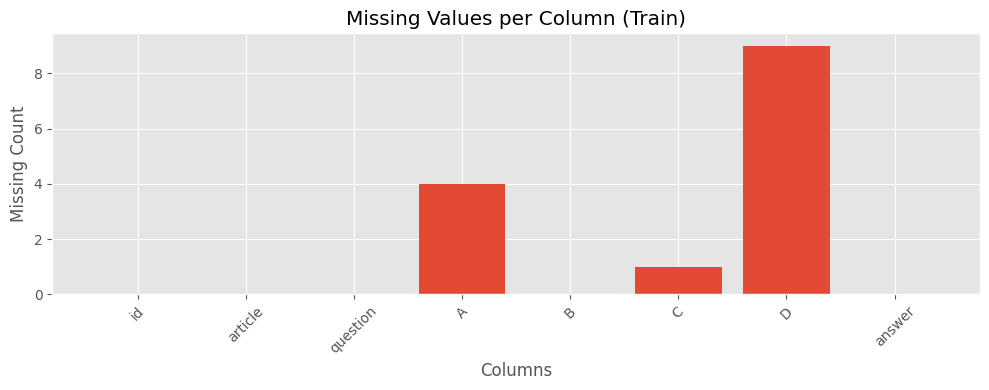

In [13]:
# ==========================================
# Cell 12: Missing values bar plot (train)
# ==========================================
miss = train_df[required_cols].isnull().sum()

plt.figure(figsize=(10, 4))
plt.bar(miss.index, miss.values)
plt.title("Missing Values per Column (Train)")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

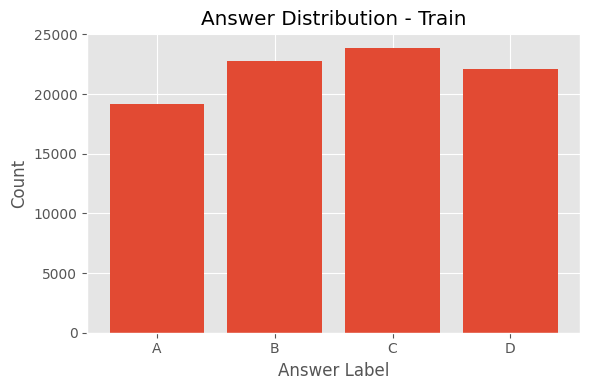

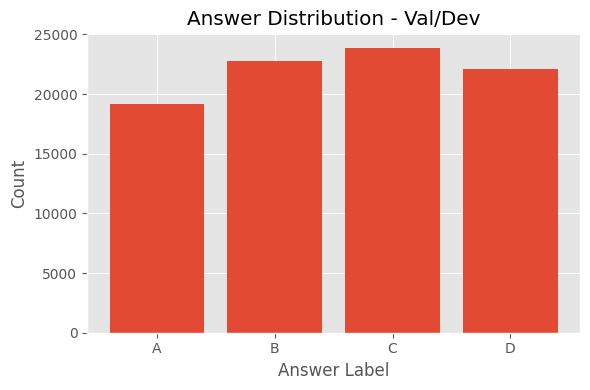

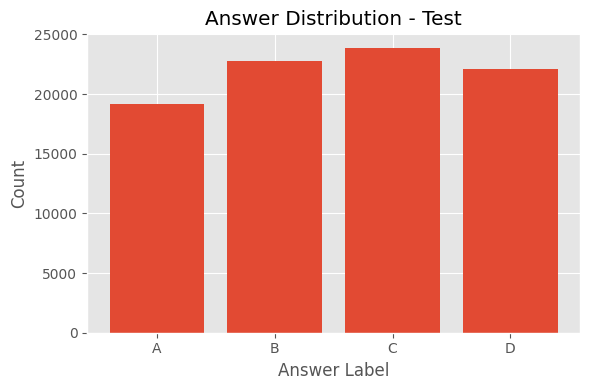

In [14]:
# ==========================================
# Cell 13: Answer distribution helper
# ==========================================
def plot_answer_distribution(df, name):
    counts = (
        df["answer"]
        .astype(str)
        .str.strip()
        .str.upper()
        .value_counts()
        .reindex(["A", "B", "C", "D"], fill_value=0)
    )

    plt.figure(figsize=(6, 4))
    plt.bar(counts.index, counts.values)
    plt.title(f"Answer Distribution - {name}")
    plt.xlabel("Answer Label")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_answer_distribution(train_df, "Train")
plot_answer_distribution(val_df, "Val/Dev")
plot_answer_distribution(test_df, "Test")

In [15]:
# ==========================================
# Cell 14: Create length features
# ==========================================
def add_length_features(df):
    out = df.copy()
    out["article_char_len"] = out["article"].astype(str).str.len()
    out["question_char_len"] = out["question"].astype(str).str.len()
    out["article_word_len"] = out["article"].astype(str).str.split().str.len()
    out["question_word_len"] = out["question"].astype(str).str.split().str.len()
    return out

train_len = add_length_features(train_df)
val_len = add_length_features(val_df)
test_len = add_length_features(test_df)

In [16]:
# ==========================================
# Cell 15: Summary stats for lengths
# ==========================================
summary_cols = ["article_char_len", "question_char_len", "article_word_len", "question_word_len"]

print("Train length summary:")
display(train_len[summary_cols].describe().T)

print("Val/Dev length summary:")
display(val_len[summary_cols].describe().T)

print("Test length summary:")
display(test_len[summary_cols].describe().T)

Train length summary:


,count,mean,std,min,25%,50%,75%,max
article_char_len,87866.0,1559.996791,577.182668,9.0,1199.0,1590.0,1882.0,6437.0
question_char_len,87866.0,52.628343,18.932038,1.0,39.0,50.0,63.0,380.0
article_word_len,87866.0,274.983702,97.881345,2.0,217.0,279.0,326.0,1162.0
question_word_len,87866.0,10.008786,3.382040,1.0,8.0,10.0,12.0,63.0


Val/Dev length summary:


,count,mean,std,min,25%,50%,75%,max
article_char_len,87866.0,1559.996791,577.182668,9.0,1199.0,1590.0,1882.0,6437.0
question_char_len,87866.0,52.628343,18.932038,1.0,39.0,50.0,63.0,380.0
article_word_len,87866.0,274.983702,97.881345,2.0,217.0,279.0,326.0,1162.0
question_word_len,87866.0,10.008786,3.382040,1.0,8.0,10.0,12.0,63.0


Test length summary:


,count,mean,std,min,25%,50%,75%,max
article_char_len,87866.0,1559.996791,577.182668,9.0,1199.0,1590.0,1882.0,6437.0
question_char_len,87866.0,52.628343,18.932038,1.0,39.0,50.0,63.0,380.0
article_word_len,87866.0,274.983702,97.881345,2.0,217.0,279.0,326.0,1162.0
question_word_len,87866.0,10.008786,3.382040,1.0,8.0,10.0,12.0,63.0


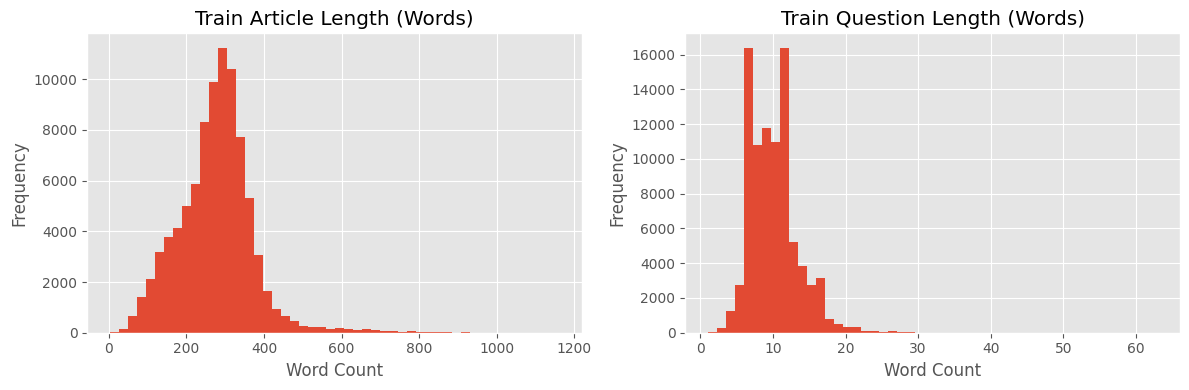

In [17]:
# ==========================================
# Cell 16: Histograms (train) - words
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_len["article_word_len"], bins=50)
axes[0].set_title("Train Article Length (Words)")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")

axes[1].hist(train_len["question_word_len"], bins=50)
axes[1].set_title("Train Question Length (Words)")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

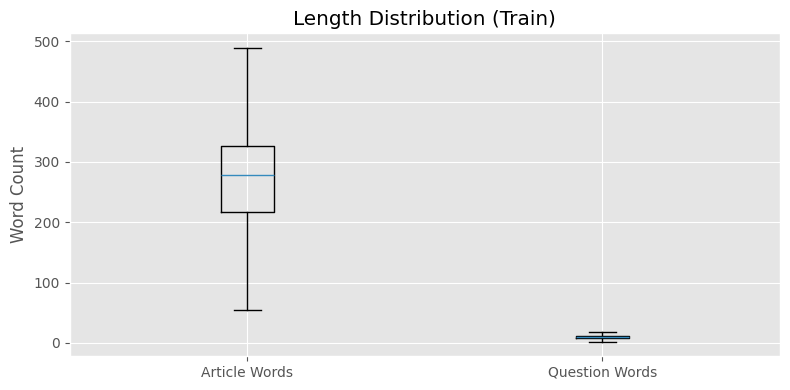

In [18]:
# ==========================================
# Cell 17: Boxplots (train) - words
# ==========================================
plt.figure(figsize=(8, 4))
plt.boxplot(
    [train_len["article_word_len"], train_len["question_word_len"]],
    tick_labels=["Article Words", "Question Words"],
    showfliers=False,
)
plt.title("Length Distribution (Train)")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()